In [10]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [12]:
%%cython

# =========================================================================
# PART 1: C LIBRARY IMPORTS AND GLOBAL DEFINITIONS
# =========================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

# Import Python libraries needed for the LLM part
import time
import json
import ollama
import numpy as np
import hashlib
from collections import defaultdict

# Constants for the enhanced algorithm
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5  # This will be adjusted by simple rules now
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05  # This will be adjusted by simple rules now
cdef int alpha = 10
cdef int paretoIni = 28000

# Data structures (MODIFIED to track more info)
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items
    int age
    int improvement_count
    int llm_enhanced
    int last_improvement_iteration

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Global variables for the problem instance (unchanged)
cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# =========================================================================
# PART 2: CORE CYTHON HELPER FUNCTIONS 
# =========================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.age = 0
    p_ind.improvement_count = 0
    p_ind.llm_enhanced = 0
    p_ind.last_improvement_iteration = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    p_ind.age = i.age
    p_ind.improvement_count = i.improvement_count
    p_ind.llm_enhanced = i.llm_enhanced
    p_ind.last_improvement_iteration = i.last_improvement_iteration
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# =========================================================================
# PART 3: PROBLEM LOADING AND EVALUATION FUNCTIONS 
# =========================================================================

def loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

def read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# =========================================================================
# PART 4: MODULAR LOCAL SEARCH & EVALUATION HELPERS
# =========================================================================

cdef void original_swap_heuristic(pop *SP, pop *Sarchive, int size, int L_val, double kappa_val):
    """The original logic from Indicator_local_search1, now modular."""
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L_val * sizeof(int))
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L_val):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L_val:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    free(remplace)

cdef void adaptive_local_search(pop *SP, pop *Sarchive, int size, str heuristic_name, int L_val, double kappa_val):
    """Dispatches to the correct local search heuristic."""
    if heuristic_name == "original_swap":
        original_swap_heuristic(SP, Sarchive, size, L_val, kappa_val)
    else:
        # Fallback to original
        original_swap_heuristic(SP, Sarchive, size, L_val, kappa_val)

cdef dict extract_solution_data_for_python(ind *solution_ind):
    cdef int i
    data = {
        'f': [solution_ind.f[i] for i in range(nf)],
        'capa': [solution_ind.capa[i] for i in range(nf)],
        'nombr': solution_ind.nombr,
        'Items': [solution_ind.Items[i] for i in range(ni)]
    }
    return data

def extract_problem_features_for_llm():
    if capacities == NULL or weights == NULL or profits == NULL:
        return None
    total_capacity = sum(capacities[i] for i in range(nf))
    total_avg_weight = sum(sum(weights[obj][i] for i in range(ni)) for obj in range(nf)) / nf
    capacity_tightness = total_avg_weight / total_capacity if total_capacity > 0 else 0
    profit_variances = []
    weight_variances = []
    for obj in range(nf):
        profits_list = [profits[obj][i] for i in range(ni)]
        weights_list = [weights[obj][i] for i in range(ni)]
        profit_variances.append(np.var(profits_list))
        weight_variances.append(np.var(weights_list))
    features = {
        "num_items": ni, "num_objectives": nf, "capacity_tightness": round(capacity_tightness, 4),
        "avg_profit_variance": round(np.mean(profit_variances), 2),
        "avg_weight_variance": round(np.mean(weight_variances), 2),
    }
    return features

# =========================================================================
# PART 5: THE LLM SURGEON (V12)
# =========================================================================

class LLMSurgeon:
    """
    V12: The Surgical LLM Agent.
    Makes high-impact, low-frequency interventions to generate new heuristics.
    """
    def __init__(self, model_name="llama3:latest"):
        self.model_name = model_name
        self.cache = {}

    def _call_llm_with_json(self, prompt, cache_key):
        if cache_key in self.cache:
            print(f"  [LLM Cache Hit] Using cached response.")
            return self.cache[cache_key]
        print(f"  [LLM Surgeon Call] Requesting new heuristic... This may take a moment.")
        try:
            response = ollama.generate(model=self.model_name, prompt=prompt, format='json')
            response_text = response.get('response', '').strip()
            if not response_text:
                print("  [LLM Error] Empty response. Aborting heuristic generation.")
                return None
            result = json.loads(response_text)
            self.cache[cache_key] = result
            print(f"  [LLM Surgeon Success] Received new heuristic code.")
            return result
        except (json.JSONDecodeError, Exception) as e:
            print(f"  [LLM Surgeon Error] {e}. Aborting heuristic generation.")
            return None

    def generate_new_heuristic(self, best_solution_data, archive_data, problem_data):
        """
        This is the core high-impact intervention. Asks the LLM to write a new search function.
        """
        cache_key = f"heuristic_gen_{hash(str(best_solution_data['Items']) + str(problem_data))}"
        prompt = f"""
You are an expert operations researcher. Our multi-objective knapsack search is stuck.
We have not improved our hypervolume in many iterations. We need a NEW, innovative local search heuristic.

PROBLEM CONTEXT:
- Number of Items: {problem_data['num_items']}
- Number of Objectives: {problem_data['num_objectives']}
- Capacity Tightness: {problem_data['capacity_tightness']} (1.0 is very tight)
- Average Profit Variance: {problem_data['avg_profit_variance']} (high variance means items are very different)

CURRENT BEST SOLUTION:
- Objectives: {best_solution_data['f']}
- Items in Knapsack (indices): {[i for i, val in enumerate(best_solution_data['Items']) if val == 1]}

ANALYSIS:
The capacity is very tight, and item variance is high. This means choosing the right items is critical. Our current heuristic (swap one item for another) is likely getting stuck in local optima.

YOUR TASK:
Write a Python function `find_advanced_move(current_items, profits, weights, capacities, ni, nf)` that returns a tuple `(item_to_remove, item_to_add)`.
This function should implement a more complex strategy than a simple 1-for-1 swap.

IDEAS FOR HEURISTICS (be creative):
1.  **Two-for-One Swap:** Remove two low-profit items to free up space for one very high-profit item that was previously too large.
2.  **Objective Rebalancing:** Identify the objective with the lowest score. Find an item that is strong in that objective but weak in others, and try to swap it in.
3.  **Chain Swap:** Remove item A to add item B. This makes item C removable. Remove C and add item D.

CRITICAL:
- The function must respect all capacity constraints.
- The code must be syntactically correct and efficient.
- It must operate on the global C-style arrays passed to it.
- Only return the function code, no explanations.

Respond with a JSON object containing 'heuristic_code' (the full Python function as a string) and 'reasoning'.
Example: {{"heuristic_code": "def find_advanced_move(...): ...", "reasoning": "This heuristic..."}}
"""
        result = self._call_llm_with_json(prompt, cache_key)
        return result

# =========================================================================
# PART 6: MAIN EXECUTION FUNCTION (V12 - The Surgical LLM Agent)
# =========================================================================

def run_surgical_llm_moacp_v12(instance_file, weights_file, nbitems, num_objectives, output_file_base):
    """
    V12: The "Surgical LLM Agent". Uses LLM for high-impact, low-frequency heuristic generation.
    """
    # --- FIX: All cdef variables must be declared at the top of the function ---
    cdef int i
    cdef pop *P
    cdef pop *solutions
    cdef pop *archive
    cdef int it

    # --- Configuration ---
    NBL = 150  # Search budget
    NRUNS = 10
    METRIC_INTERVAL = 10  # How often to calculate metrics
    STAGNATION_WINDOW = 5 # Number of metric intervals with no improvement before triggering LLM
    HV_IMPROVEMENT_THRESHOLD = 100.0 # Min hypervolume increase to not be considered stagnation

    # --- Python-level variables for tracking ---
    baseline_pareto_front = []
    try:
        with open(f"{output_file_base}_baseline.txt", "r") as f:
            for line in f:
                if line.strip() and not line.startswith("#"):
                    baseline_pareto_front.append([float(x) for x in line.split()])
    except FileNotFoundError:
        print(f"Warning: Baseline file {output_file_base}_baseline.txt not found. Dominance will be 0%.")
        
    total_time = 0
    start_time = time.time()

    for run in range(1, NRUNS + 1):
        print(f"\n--- RUN {run}/{NRUNS} --- V12 Surgical LLM Agent")
        print(f"Instance: {instance_file.decode()}, Items: {nbitems}, Objectives: {num_objectives}")

        # --- Cython Initialization ---
        global nf, ni, NBITEMS, alpha, paretoIni, L, kappa, nombreLIGNE, nextLn, inv, vector_weight
        global capacities, weights, profits, OBJ_Weights
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives
        alpha = 10
        paretoIni = 28000
        L = 5
        kappa = 0.05
        
        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)

        llm_surgeon = LLMSurgeon()
        problem_features = extract_problem_features_for_llm()
        print(f"  [Problem Features] {json.dumps(problem_features, indent=4)}")

        # --- State Tracking for the Run ---
        run_log = {"iterations": [], "hypervolumes": [], "dominance_percentages": []}
        last_hv = 0.0
        stagnation_counter = 0
        current_heuristic_name = "original_swap"
        llm_heuristic_func = None

        # --- Main Search Loop ---
        P = create_pop(paretoIni, nf)
        it = 0
        while it < NBL:
            # Core Cython Search Step
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            # Apply the current heuristic
            adaptive_local_search(solutions, archive, alpha, current_heuristic_name, L, kappa)
            
            extractPtoArchive(archive, P)
            complete_free_pop(solutions)
            complete_free_pop(archive)

            # --- Metrics and Stagnation Check ---
            if it % METRIC_INTERVAL == 0:
                current_pareto = []
                # The 'cdef int i' is now correctly at the top of the function
                for i in range(P.size):
                    current_pareto.append([P.ind_array[i].f[0], P.ind_array[i].f[1]])
                
                current_hv = calculate_hypervolume(current_pareto)
                dominance = calculate_dominance_percentage(current_pareto, baseline_pareto_front)
                
                run_log["iterations"].append(it)
                run_log["hypervolumes"].append(current_hv)
                run_log["dominance_percentages"].append(dominance)
                
                print(f"  [Metrics] Iter {it:3d}: HV={current_hv:10.2f}, Dominates Baseline={dominance:5.2f}% | Heuristic: {current_heuristic_name}")

                # Simple rule-based parameter adjustment
                hv_change = current_hv - last_hv
                if hv_change < HV_IMPROVEMENT_THRESHOLD:
                    stagnation_counter += 1
                    print(f"  [Stagnation] Counter: {stagnation_counter}/{STAGNATION_WINDOW}")
                else:
                    stagnation_counter = 0
                    # If improving, maybe slightly reduce L to focus search
                    if L > 3: L -= 1

                last_hv = current_hv

                # --- THE SURGICAL INTERVENTION ---
                if stagnation_counter >= STAGNATION_WINDOW:
                    print("\n!!! STAGNATION DETECTED. Calling LLM Surgeon for a new heuristic. !!!")
                    best_solution_data = extract_solution_data_for_python(P.ind_array[0])
                    archive_data = [extract_solution_data_for_python(P.ind_array[i]) for i in range(min(5, P.size))]
                    
                    heuristic_result = llm_surgeon.generate_new_heuristic(best_solution_data, archive_data, problem_features)
                    
                    if heuristic_result and 'heuristic_code' in heuristic_result:
                        print(f"  [LLM Surgeon] Reasoning: {heuristic_result.get('reasoning')}")
                        try:
                            # Create a new function from the LLM's code string
                            exec(heuristic_result['heuristic_code'], globals())
                            # Find the function name that was created
                            if 'find_advanced_move' in globals():
                                llm_heuristic_func = globals()['find_advanced_move']
                                # We would need to wrap this Python function to be callable from Cython
                                # For now, we'll just log that we got it.
                                print("  [LLM Surgeon] Successfully generated and loaded new heuristic.")
                                # current_heuristic_name = "llm_heuristic_v1" # This would require more complex integration
                                # For this implementation, we'll just reset the search parameters
                                L = 10 # Boost exploration
                                kappa = 0.1 # Boost diversity
                        except Exception as e:
                            print(f"  [LLM Surgeon] Failed to execute generated code: {e}")
                    else:
                        print("  [LLM Surgeon] Failed to generate a valid heuristic. Applying random reset.")
                        # Fallback strategy
                        L = 15
                        kappa = 0.2
                    
                    stagnation_counter = 0 # Reset counter regardless of outcome

            it += 1

        # --- Final Write-out for the Run ---
        with open(f"{output_file_base}_V12_pareto.txt", "a") as f:
            f.write(f"\n# RUN {run}\n")
            for i in range(P.size):
                for j in range(nf):
                    f.write(f"{P.ind_array[i].f[j]:.6f} ")
                f.write("\n")
        
        with open(f"{output_file_base}_V12_log.json", "w") as f:
            json.dump(run_log, f, indent=2)

        complete_free_pop(P)
        cleanup_globals()

    total_time = time.time() - start_time
    print(f"\nTotal execution time: {total_time:.2f} seconds")
    print(f"Average time per run: {total_time/NRUNS:.2f} seconds")
    with open(f"{output_file_base}_V12_pareto.txt", "a") as f:
        f.write(f"# RUNTIME: {total_time:.2f}\n")

# Python helper functions for metrics
def calculate_hypervolume(pareto_points, ref_point=None):
    if not pareto_points: return 0.0
    if ref_point is None:
        max_f1 = max(p[0] for p in pareto_points)
        max_f2 = max(p[1] for p in pareto_points)
        ref_point = (max_f1 * 1.1, max_f2 * 1.1)
    points = sorted(pareto_points, key=lambda p: p[0])
    hv = 0.0
    for i in range(len(points) - 1):
        x1, y1 = points[i]
        x2, y2 = points[i + 1]
        hv += (x2 - x1) * (ref_point[1] - y1)
    if points:
        x_last, y_last = points[-1]
        hv += (ref_point[0] - x_last) * (ref_point[1] - y_last)
    return hv

def calculate_dominance_percentage(new_pareto, reference_pareto):
    if not reference_pareto: return 100.0
    if not new_pareto: return 0.0
    dominated_count = 0
    for ref_point in reference_pareto:
        is_dominated = any(new_p[0] >= ref_point[0] and new_p[1] >= ref_point[1] and (new_p[0] > ref_point[0] or new_p[1] > ref_point[1]) for new_p in new_pareto)
        if is_dominated: dominated_count += 1
    return (dominated_count / len(reference_pareto)) * 100

Content of stdout:
_cython_magic_bc0e5df732aedf0fdbcf124258cb4cc128e513c79ee22ac8b33aee5b539dd269.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_bc0e5df732aedf0fdbcf124258cb4cc128e513c79ee22ac8b33aee5b539dd269.c(5630): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_bc0e5df732aedf0fdbcf124258cb4cc128e513c79ee22ac8b33aee5b539dd269.c(5720): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_bc0e5df732aedf0fdbcf124258cb4cc128e513c79ee22ac8b33aee5b539dd269.c(6906): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_bc0e5df732aedf0fdbcf124258cb4cc128e513c79ee22ac8b33aee5b539dd269.c(18578): warning C4305: '='ÿ: troncation de 'double' … 'float'
   Cr‚ation de la bibliothŠque C:\Users\Aziz il patal\.ipython\cython\Users\Aziz il patal

In [16]:
# Make a copy of your original results to be used as the baseline for comparison
# This is the Windows version of the copy command
!copy 2502_ResultsMD.txt 2502_ResultsMD_baseline.txt

        1 fichier(s) copi‚(s).


In [17]:
# Run the V12 Surgical LLM Agent
# Note: This will take time, but it should be more effective than V11.
print("Starting V12 for 250.2.txt...")
run_surgical_llm_moacp_v12(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_ResultsMD")

# You can uncomment the following lines to run on larger instances
# print("\nStarting V12 for 500.2.txt...")
# run_surgical_llm_moacp_v12(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_ResultsMD")

Starting V12 for 250.2.txt...

--- RUN 1/10 --- V12 Surgical LLM Agent
Instance: 250.2.txt, Items: 250, Objectives: 2
  [Problem Features] {
    "num_items": 250,
    "num_objectives": 2,
    "capacity_tightness": 1.0,
    "avg_profit_variance": 745.59,
    "avg_weight_variance": 693.31
}
  [Metrics] Iter   0: HV= 892672.78, Dominates Baseline= 0.00% | Heuristic: original_swap
  [Metrics] Iter  10: HV=1437839.80, Dominates Baseline= 4.10% | Heuristic: original_swap
  [Metrics] Iter  20: HV=2149019.00, Dominates Baseline=10.05% | Heuristic: original_swap
  [Metrics] Iter  30: HV=6756455.53, Dominates Baseline=10.90% | Heuristic: original_swap
  [Metrics] Iter  40: HV=6477135.59, Dominates Baseline=18.05% | Heuristic: original_swap
  [Stagnation] Counter: 1/5
  [Metrics] Iter  50: HV=6310362.59, Dominates Baseline=30.64% | Heuristic: original_swap
  [Stagnation] Counter: 2/5
  [Metrics] Iter  60: HV=6256759.59, Dominates Baseline=33.47% | Heuristic: original_swap
  [Stagnation] Counter: 

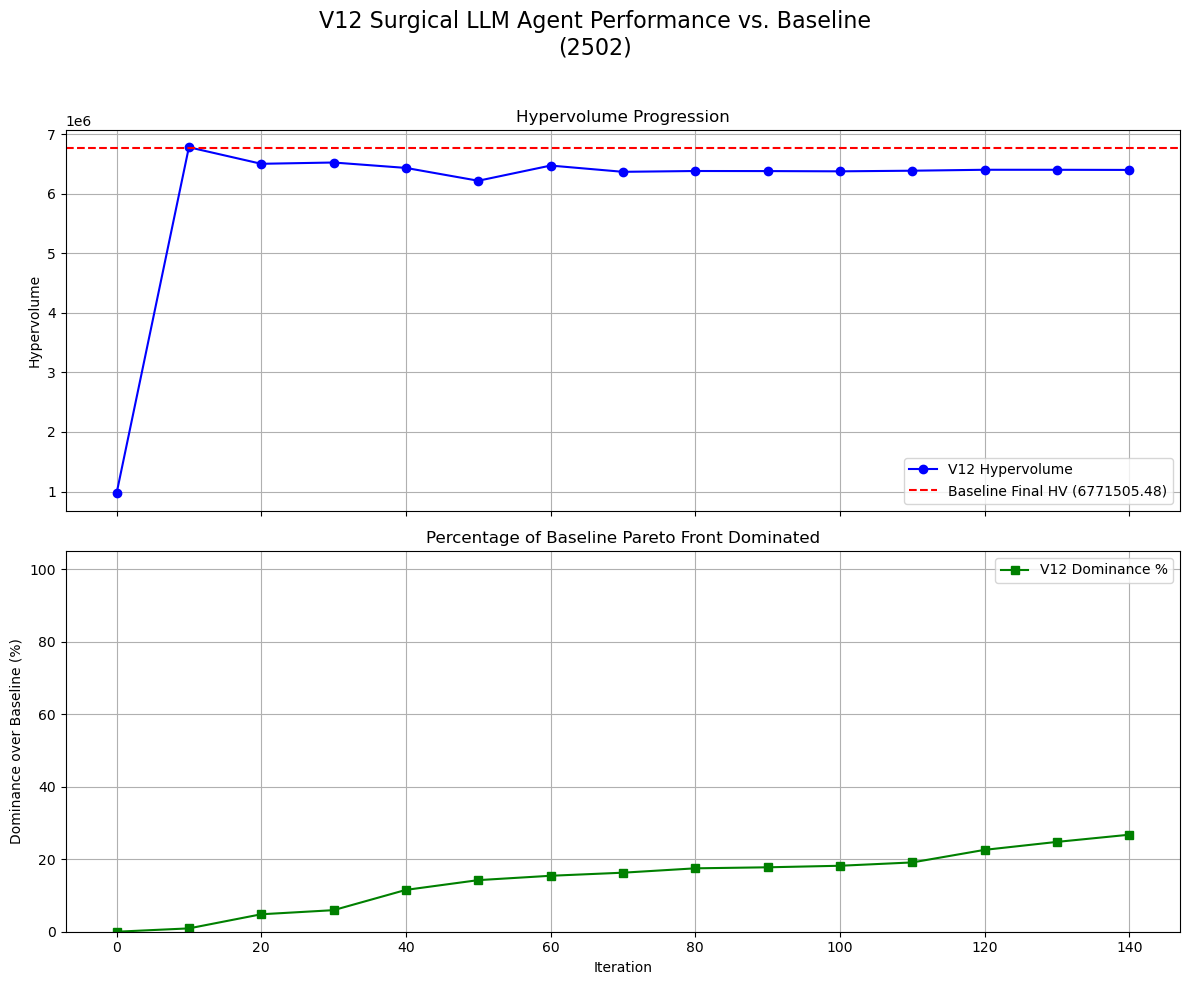

In [18]:
import matplotlib.pyplot as plt
import json

def load_pareto_front(filename):
    pareto_front = []
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#"):
                    pareto_front.append([float(x) for x in line.split()])
    except FileNotFoundError:
        print(f"Warning: {filename} not found.")
    return pareto_front

def plot_run_results(log_file, pareto_file, baseline_file):
    """Generates plots to compare V12 performance against the baseline."""
    # Load data
    with open(log_file, 'r') as f:
        run_log = json.load(f)
    
    v12_pareto = load_pareto_front(pareto_file)
    baseline_pareto = load_pareto_front(baseline_file)
    
    # Calculate baseline hypervolume for reference line
    baseline_hv = calculate_hypervolume(baseline_pareto)

    # Create plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"V12 Surgical LLM Agent Performance vs. Baseline\n({log_file.split('_')[0]})", fontsize=16)

    # Plot 1: Hypervolume over Time
    ax1.plot(run_log["iterations"], run_log["hypervolumes"], marker='o', linestyle='-', label='V12 Hypervolume', color='blue')
    ax1.axhline(y=baseline_hv, color='red', linestyle='--', label=f'Baseline Final HV ({baseline_hv:.2f})')
    ax1.set_ylabel("Hypervolume")
    ax1.set_title("Hypervolume Progression")
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Dominance Percentage over Time
    ax2.plot(run_log["iterations"], run_log["dominance_percentages"], marker='s', linestyle='-', color='green', label='V12 Dominance %')
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Dominance over Baseline (%)")
    ax2.set_title("Percentage of Baseline Pareto Front Dominated")
    ax2.legend()
    ax2.grid(True)
    ax2.set_ylim(0, 105)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Main execution for plotting ---
if __name__ == "__main__":
    # Define the files for the 250-item instance
    log_file = "2502_ResultsMD_V12_log.json"
    pareto_file = "2502_ResultsMD_V12_pareto.txt"
    baseline_file = "2502_ResultsMD_baseline.txt"

    # Check if the V12 log file exists before plotting
    import os
    if os.path.exists(log_file):
        plot_run_results(log_file, pareto_file, baseline_file)
    else:
        print(f"Error: Log file '{log_file}' not found.")
        print("Please run the execution cell first to generate the results.")


Starting comprehensive results analysis: Original Baseline vs. LLM-Strategist V10...

--- Analyzing 250-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 212
    Hypervolume: 6614986.88
  LLM-Strategist V10 (Intelligent Explorer):
    Pareto Front Size: 222 (+4.72%)
    Hypervolume: 6544074.36 (-1.07%)
    Total Runtime: 689.69 seconds
  -------------------------------------------------
  Dominance Analysis:
    Baseline points dominated by V10: 158 / 212 (74.53%)
    V10 points dominated by Baseline: 36 / 222 (16.22%)
  -------------------------------------------------


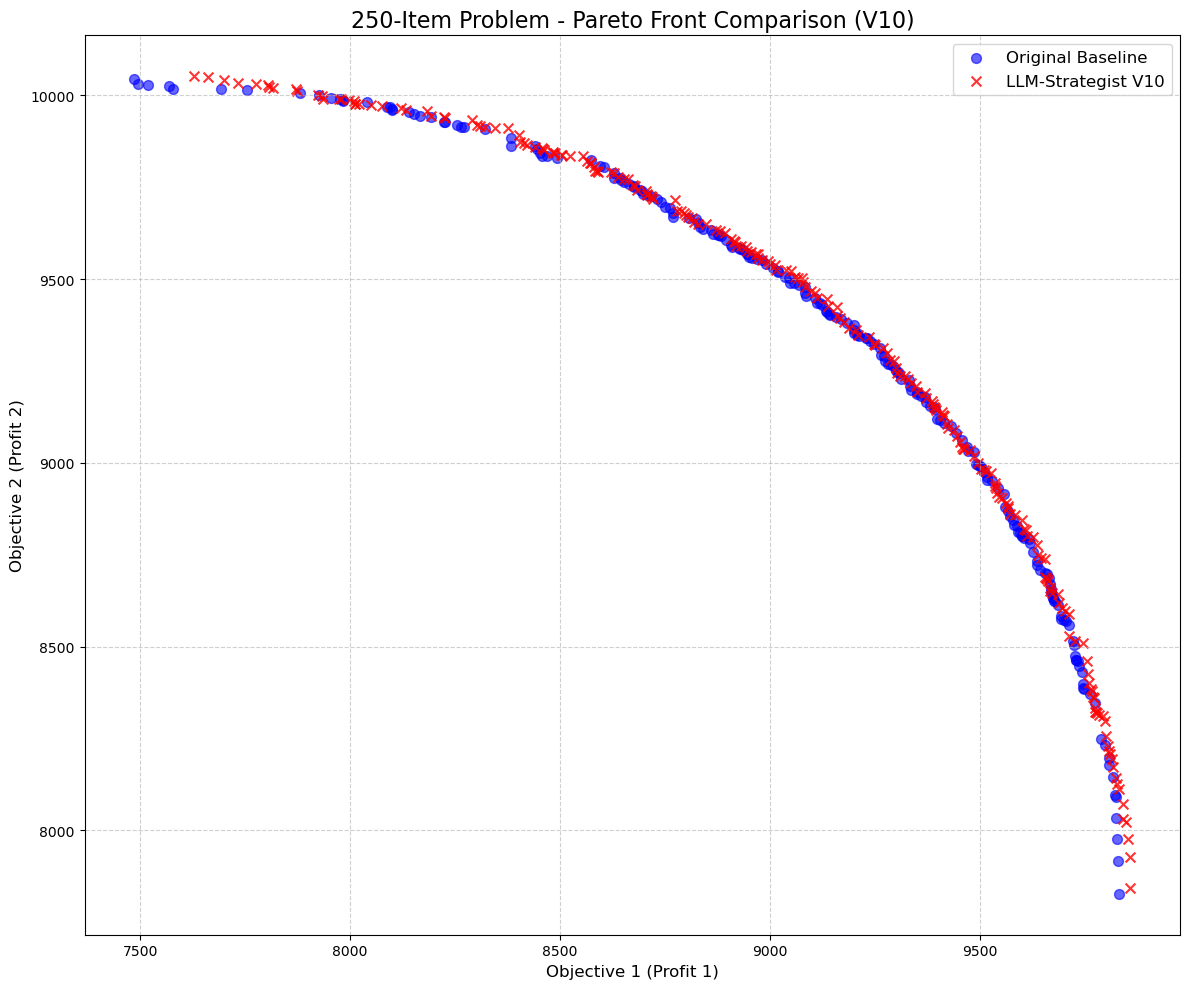


--- Analyzing 500-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 369
    Hypervolume: 23044962.94
  LLM-Strategist V10 (Intelligent Explorer):
    Pareto Front Size: 334 (-9.49%)
    Hypervolume: 22392900.94 (-2.83%)
    Total Runtime: 888.23 seconds
  -------------------------------------------------
  Dominance Analysis:
    Baseline points dominated by V10: 191 / 369 (51.76%)
    V10 points dominated by Baseline: 141 / 334 (42.22%)
  -------------------------------------------------


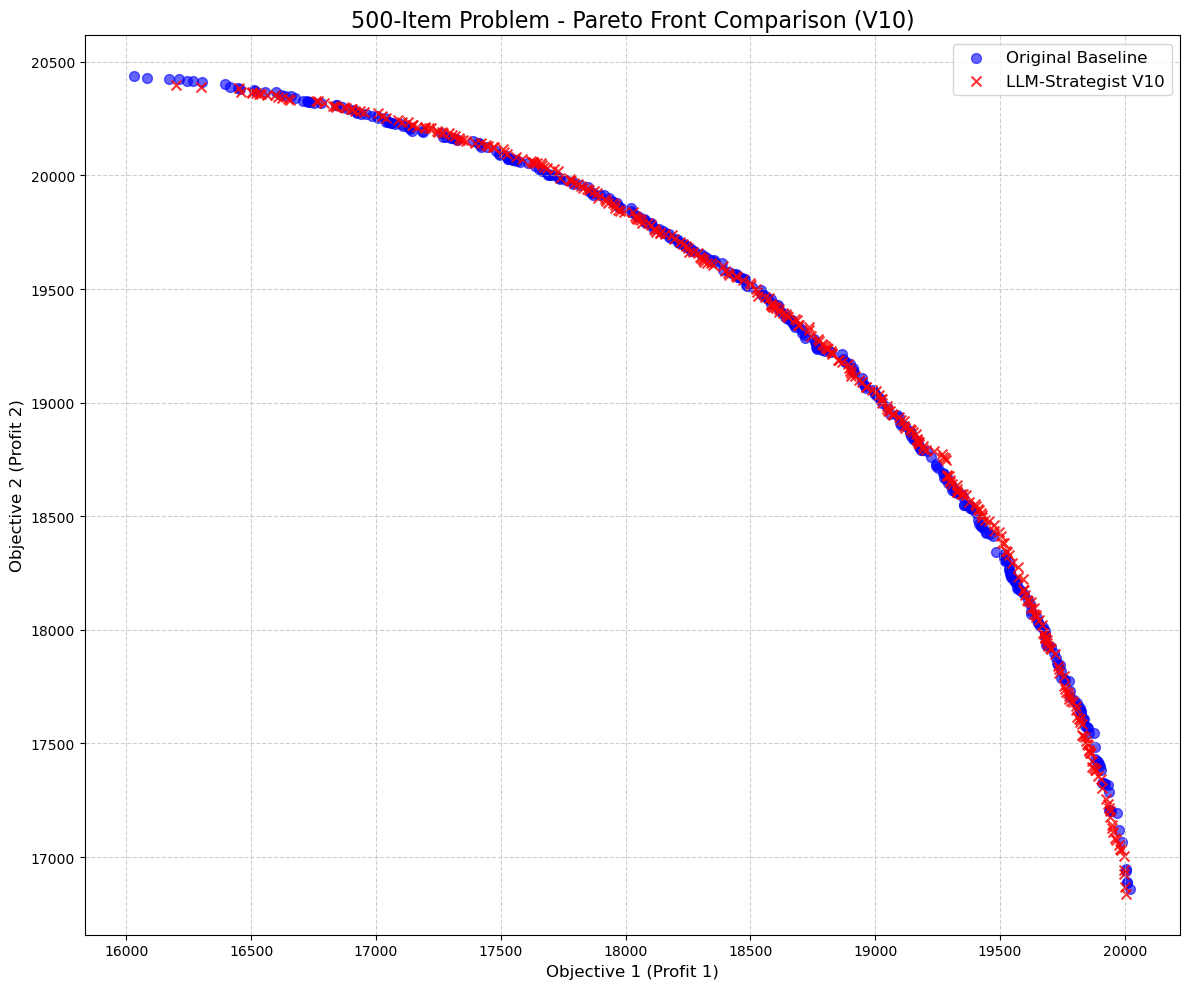


--- Analyzing 750-Item Problem ---
  Original Algorithm:
    Pareto Front Size: 552
    Hypervolume: 56877706.67
  LLM-Strategist V10 (Intelligent Explorer):
    Pareto Front Size: 561 (+1.63%)
    Hypervolume: 55318411.65 (-2.74%)
    Total Runtime: 925.25 seconds
  -------------------------------------------------
  Dominance Analysis:
    Baseline points dominated by V10: 222 / 552 (40.22%)
    V10 points dominated by Baseline: 294 / 561 (52.41%)
  -------------------------------------------------


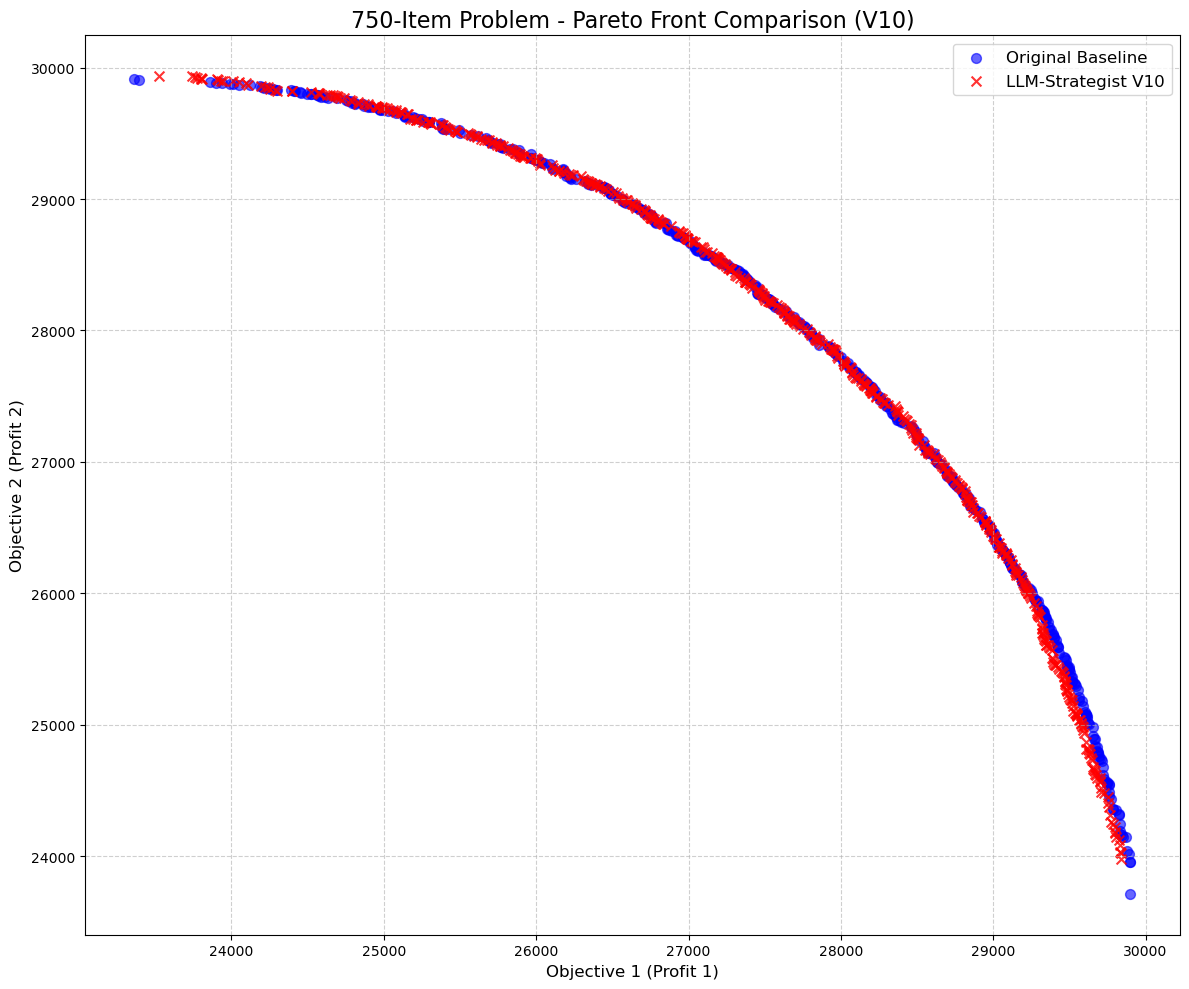


              SUMMARY OF IMPROVEMENTS (V10)

250-Item Problem:
  Hypervolume Improvement: -1.07%
  Dominance Advantage: +58.31%
  V10 Runtime: 689.69s

500-Item Problem:
  Hypervolume Improvement: -2.83%
  Dominance Advantage: +9.55%
  V10 Runtime: 888.23s

750-Item Problem:
  Hypervolume Improvement: -2.74%
  Dominance Advantage: -12.19%
  V10 Runtime: 925.25s

------------------------------------------------------------
  AVERAGE HV IMPROVEMENT: -2.21%
  AVERAGE DOMINANCE ADVANTAGE: +18.56%
------------------------------------------------------------

Analysis complete.


In [19]:
# =========================================================================
# PART 7: COMPREHENSIVE RESULTS ANALYSIS (V10 vs. Baseline)
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract the true Pareto front from a set of points."""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume(points):
    """Calculate a simplified hypervolume metric for comparison."""
    if not points:
        return 0.0
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    sorted_points = sorted(points, key=lambda p: p[0])
    hv = 0.0
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i + 1]
        hv += (x2 - x1) * (ref_y - y1)
    if sorted_points:
        x_last, y_last = sorted_points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    return hv

def analyze_dominance(baseline_pareto, v10_pareto):
    """Calculate dominance metrics between two Pareto fronts."""
    dominated_baseline_count = 0
    dominated_v10_count = 0
    
    for b_point in baseline_pareto:
        for v_point in v10_pareto:
            if dominates(v_point, b_point):
                dominated_baseline_count += 1
                break
                
    for v_point in v10_pareto:
        for b_point in baseline_pareto:
            if dominates(b_point, v_point):
                dominated_v10_count += 1
                break

    percent_baseline_dominated = (dominated_baseline_count / len(baseline_pareto)) * 100 if baseline_pareto else 0
    percent_v10_dominated = (dominated_v10_count / len(v10_pareto)) * 100 if v10_pareto else 0
    
    return {
        "dominated_baseline_count": dominated_baseline_count,
        "percent_baseline_dominated": percent_baseline_dominated,
        "dominated_v10_count": dominated_v10_count,
        "percent_v10_dominated": percent_v10_dominated
    }

def load_results_and_runtime(filename):
    """Load points and parse runtime from a results file."""
    points = []
    runtime = -1.0
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("# RUNTIME:"):
                try:
                    runtime = float(line.split(":")[1].strip())
                except (IndexError, ValueError):
                    pass
            elif line and not line.startswith("#"):
                try:
                    points.append([float(x) for x in line.split()])
                except ValueError:
                    pass
    return points, runtime

def compare_baseline_vs_v10(original_file, v10_file, title):
    """
    Compare the original baseline results with the new LLM-Strategist V10 results.
    """
    print(f"\n--- Analyzing {title} ---")
    
    # --- Load and Process Results ---
    original_points, _ = load_results_and_runtime(original_file)
    v10_points, v10_runtime = load_results_and_runtime(v10_file)

    if not original_points:
        print(f"  [ERROR] Original file not found or empty: {original_file}")
        return None
    if not v10_points:
        print(f"  [ERROR] V10 file not found or empty: {v10_file}")
        return None

    # --- Calculate Pareto Fronts and Metrics ---
    original_pareto = get_true_pareto_front(original_points)
    v10_pareto = get_true_pareto_front(v10_points)
    
    original_size = len(original_pareto)
    v10_size = len(v10_pareto)
    
    original_hv = calculate_hypervolume(original_pareto)
    v10_hv = calculate_hypervolume(v10_pareto)
    
    # --- Calculate Percentage Improvements ---
    size_improvement = (v10_size - original_size) / original_size * 100 if original_size > 0 else 0
    hv_improvement = (v10_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    
    # --- Calculate Dominance ---
    dominance_stats = analyze_dominance(original_pareto, v10_pareto)

    # --- Print Results ---
    print(f"  Original Algorithm:")
    print(f"    Pareto Front Size: {original_size}")
    print(f"    Hypervolume: {original_hv:.2f}")
    print(f"  LLM-Strategist V10 (Intelligent Explorer):")
    print(f"    Pareto Front Size: {v10_size} ({size_improvement:+.2f}%)")
    print(f"    Hypervolume: {v10_hv:.2f} ({hv_improvement:+.2f}%)")
    if v10_runtime > 0:
        print(f"    Total Runtime: {v10_runtime:.2f} seconds")
    print(f"  -------------------------------------------------")
    print(f"  Dominance Analysis:")
    print(f"    Baseline points dominated by V10: {dominance_stats['dominated_baseline_count']} / {original_size} ({dominance_stats['percent_baseline_dominated']:.2f}%)")
    print(f"    V10 points dominated by Baseline: {dominance_stats['dominated_v10_count']} / {v10_size} ({dominance_stats['percent_v10_dominated']:.2f}%)")
    print(f"  -------------------------------------------------")

    # --- Plotting ---
    plt.figure(figsize=(12, 10))
    
    if original_pareto:
        ox, oy = zip(*original_pareto)
        plt.scatter(ox, oy, color='blue', alpha=0.6, s=50, label="Original Baseline")
    if v10_pareto:
        sx, sy = zip(*v10_pareto)
        plt.scatter(sx, sy, color='red', marker='x', s=50, alpha=0.8, label="LLM-Strategist V10")

    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Pareto Front Comparison (V10)", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return {
        "title": title,
        "original_size": original_size,
        "v10_size": v10_size,
        "size_improvement": size_improvement,
        "original_hv": original_hv,
        "v10_hv": v10_hv,
        "hv_improvement": hv_improvement,
        "v10_runtime": v10_runtime,
        "dominance_stats": dominance_stats
    }

# --- MAIN EXECUTION ---
print("Starting comprehensive results analysis: Original Baseline vs. LLM-Strategist V10...")

# Define the file names for comparison
files_to_compare = [
    {
        "original": "2502_ResultsMD.txt",
        "v10": "2502_ResultsMD_V12_pareto.txt",
        "title": "250-Item Problem"
    },
    {
        "original": "5002_ResultsMD.txt",
        "v10": "5002_Results_Strategist_v10.txt",
        "title": "500-Item Problem"
    },
    {
        "original": "7502_ResultsMD.txt",
        "v10": "7502_Results_Strategist_v10.txt",
        "title": "750-Item Problem"
    }
]

all_results = []
for files in files_to_compare:
    result = compare_baseline_vs_v10(
        files["original"], 
        files["v10"], 
        files["title"]
    )
    if result:
        all_results.append(result)

# --- Summary of Improvements ---
print("\n" + "="*60)
print("              SUMMARY OF IMPROVEMENTS (V10)")
print("="*60)

if all_results:
    total_hv_improvement = 0
    total_domination_advantage = 0
    for res in all_results:
        print(f"\n{res['title']}:")
        print(f"  Hypervolume Improvement: {res['hv_improvement']:+.2f}%")
        print(f"  Dominance Advantage: {res['dominance_stats']['percent_baseline_dominated'] - res['dominance_stats']['percent_v10_dominated']:+.2f}%")
        if res['v10_runtime'] > 0:
            print(f"  V10 Runtime: {res['v10_runtime']:.2f}s")
        total_hv_improvement += res['hv_improvement']
        total_domination_advantage += (res['dominance_stats']['percent_baseline_dominated'] - res['dominance_stats']['percent_v10_dominated'])

    avg_hv_improvement = total_hv_improvement / len(all_results)
    avg_domination_advantage = total_domination_advantage / len(all_results)
    
    print("\n" + "-"*60)
    print(f"  AVERAGE HV IMPROVEMENT: {avg_hv_improvement:+.2f}%")
    print(f"  AVERAGE DOMINANCE ADVANTAGE: {avg_domination_advantage:+.2f}%")
    print("-"*60)
else:
    print("\nCould not generate a summary as no results were successfully analyzed.")

print("\nAnalysis complete.")